=== Application Train Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None

=== First 5 Rows ===
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3  

Imputed missing values in OWN_CAR_AGE with median: 9.0
Imputed missing values in OCCUPATION_TYPE with mode: Laborers
Imputed missing values in CNT_FAM_MEMBERS with median: 2.0
Imputed missing values in EXT_SOURCE_1 with median: 0.5059979305057544
Imputed missing values in EXT_SOURCE_2 with median: 0.5659614260608526
Imputed missing values in EXT_SOURCE_3 with median: 0.5352762504724826
Imputed missing values in APARTMENTS_AVG with median: 0.0876
Imputed missing values in BASEMENTAREA_AVG with median: 0.0763
Imputed missing values in YEARS_BEGINEXPLUATATION_AVG with median: 0.9816
Imputed missing values in YEARS_BUILD_AVG with median: 0.7552
Imputed missing values in COMMONAREA_AVG with median: 0.0211
Imputed missing values in ELEVATORS_AVG with median: 0.0
Imputed missing values in ENTRANCES_AVG with median: 0.1379
Imputed missing values in FLOORSMAX_AVG with median: 0.1667
Imputed missing values in FLOORSMIN_AVG with median: 0.2083
Imputed missing values in LANDAREA_AVG with median: 0

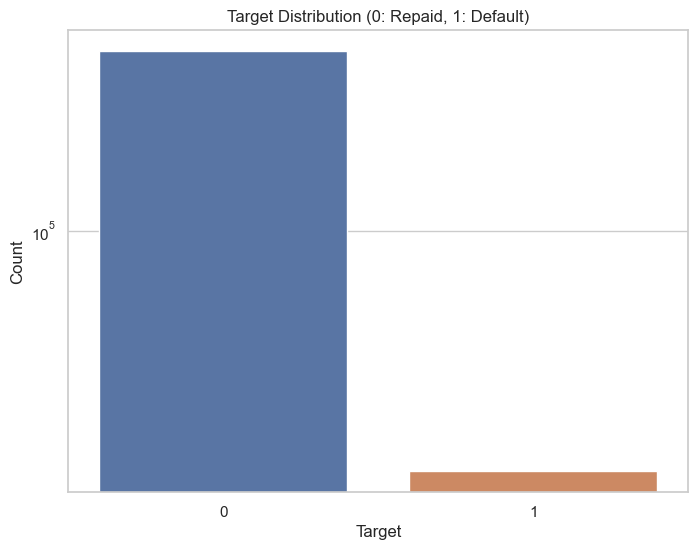

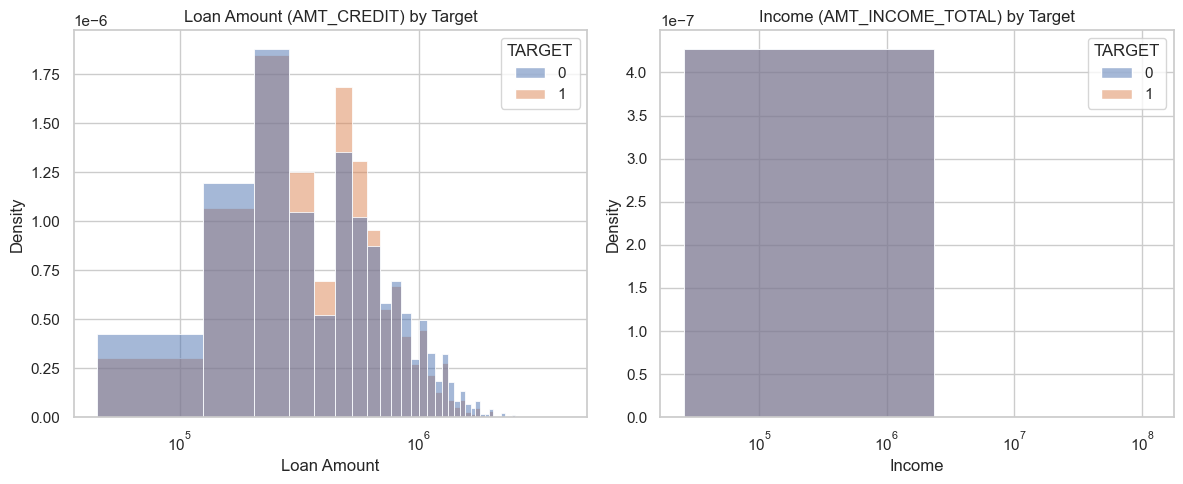

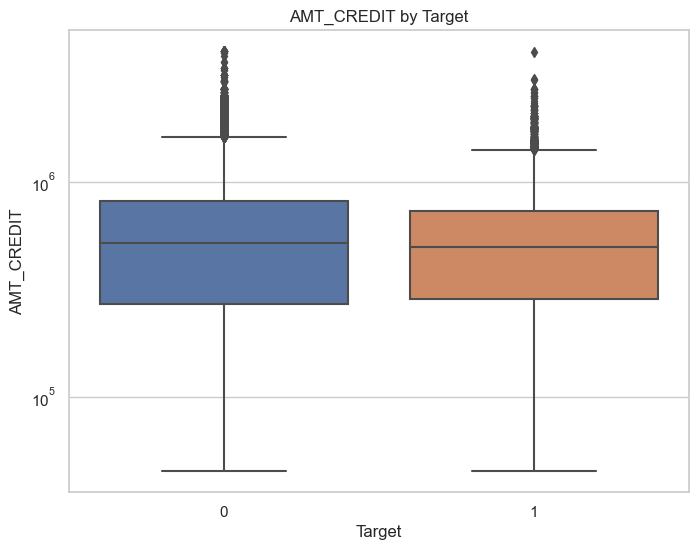

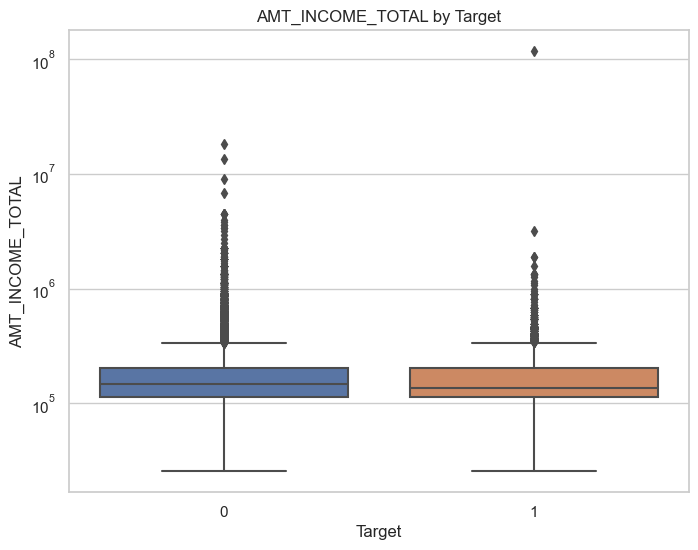

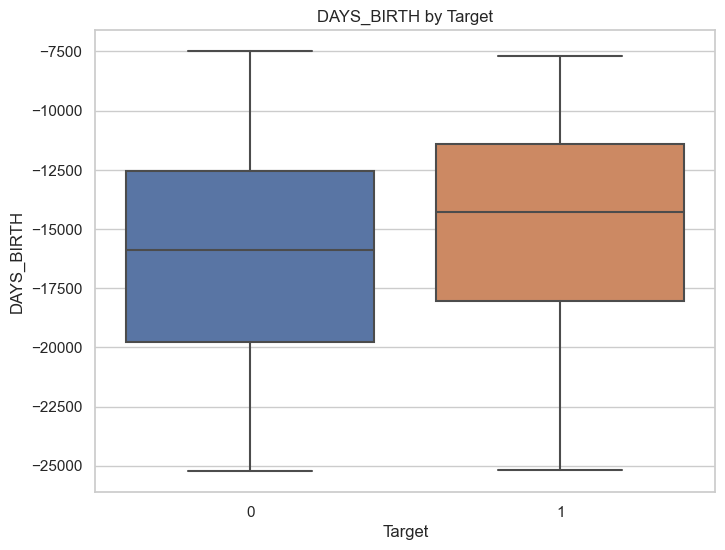

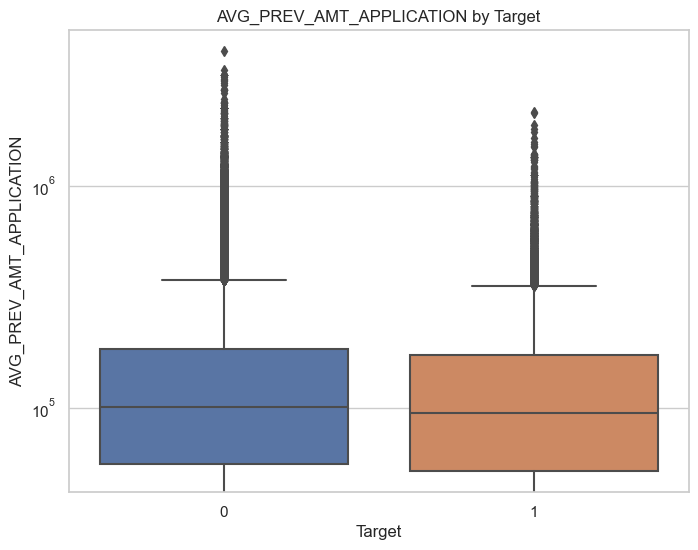

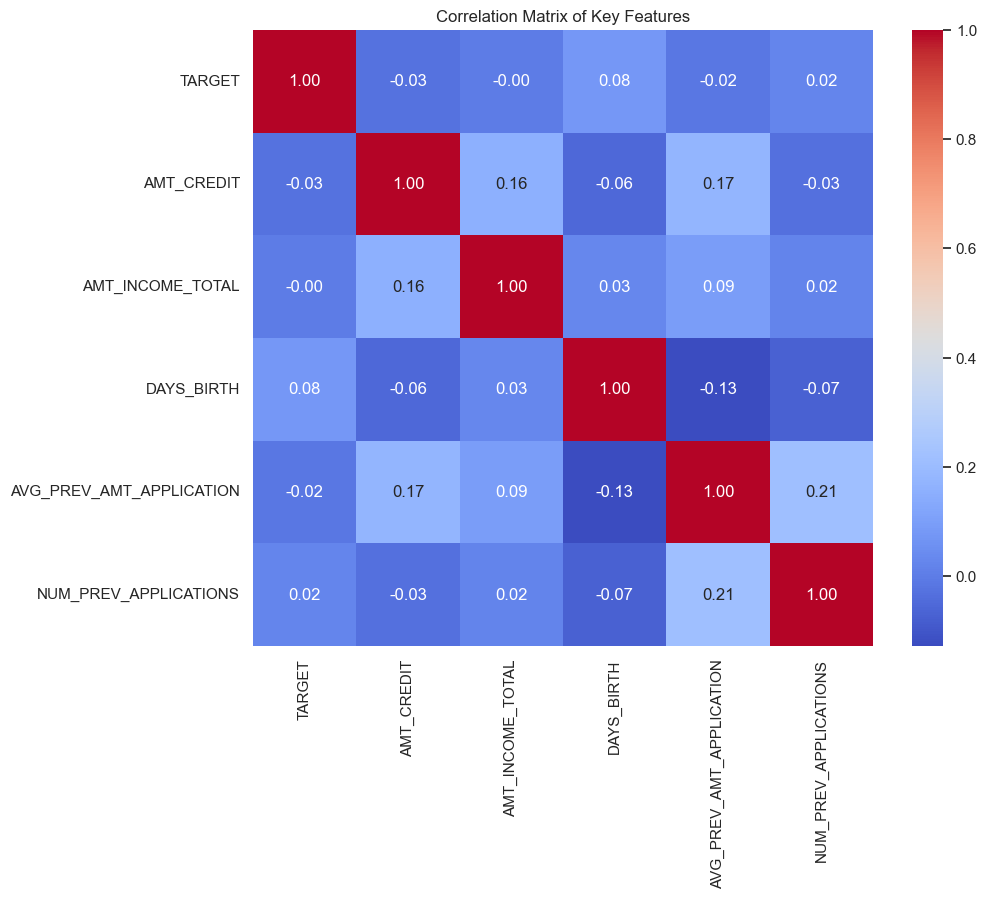

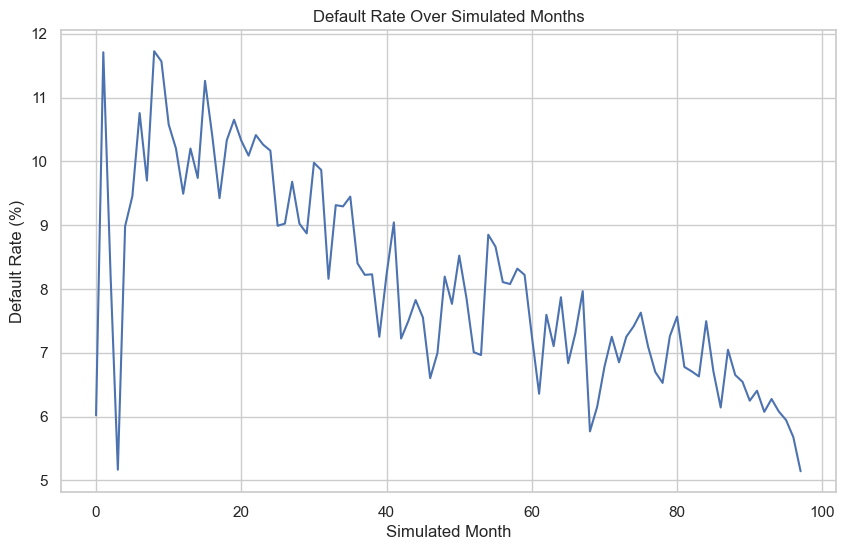


Processed dataset saved. EDA completed.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# File paths
base_path = r"C:\Users\Sanu\Downloads\archive (10)"
app_train_path = f"{base_path}\HC_application_train.csv"
prev_app_path = f"{base_path}\HC_previous_application.csv"

# Load main dataset
df_app = pd.read_csv(app_train_path)
print("=== Application Train Overview ===")
print(df_app.info())
print("\n=== First 5 Rows ===")
print(df_app.head())

# Load previous applications
df_prev = pd.read_csv(prev_app_path)
print("\n=== Previous Applications Overview ===")
print(df_prev.info())
print("\n=== First 5 Rows ===")
print(df_prev.head())

# 1. Data Cleaning

# Remove duplicates from application_train
duplicates = df_app.duplicated().sum()
print(f"\nNumber of duplicate rows in application_train: {duplicates}")
if duplicates > 0:
    df_app = df_app.drop_duplicates()
    print("Duplicates removed from application_train.")

# 2. Handle Missing Values

print("\n=== Missing Values in Application Train ===")
missing_values = df_app.isnull().sum()
print(missing_values[missing_values > 0])

# Impute numerical columns with median, categorical with mode
for col in df_app.columns:
    if df_app[col].isnull().sum() > 0:
        if df_app[col].dtype in ['float64', 'int64']:
            median_val = df_app[col].median()
            df_app[col].fillna(median_val, inplace=True)
            print(f"Imputed missing values in {col} with median: {median_val}")
        else:
            mode_val = df_app[col].mode()[0]
            df_app[col].fillna(mode_val, inplace=True)
            print(f"Imputed missing values in {col} with mode: {mode_val}")

# 3. Merge with Previous Applications
df_prev_agg = df_prev.groupby('SK_ID_CURR').agg({
    'AMT_APPLICATION': 'mean',
    'DAYS_DECISION': 'min',
    'SK_ID_PREV': 'count'
}).rename(columns={
    'AMT_APPLICATION': 'AVG_PREV_AMT_APPLICATION',
    'DAYS_DECISION': 'EARLIEST_DAYS_DECISION',
    'SK_ID_PREV': 'NUM_PREV_APPLICATIONS'
}).reset_index()

df = df_app.merge(df_prev_agg, on='SK_ID_CURR', how='left')
print("\nMerged dataset shape:", df.shape)

# Fill missing values after merge
df['AVG_PREV_AMT_APPLICATION'].fillna(0, inplace=True)
df['NUM_PREV_APPLICATIONS'].fillna(0, inplace=True)
df['EARLIEST_DAYS_DECISION'].fillna(0, inplace=True)

# 4. Infer Timeline for Rolling Window
df['SIMULATED_MONTH'] = (df['EARLIEST_DAYS_DECISION'].abs() // 30).astype(int)
print("\nSimulated timeline created using EARLIEST_DAYS_DECISION.")

# 5. Exploratory Data Analysis (EDA)

# Summary statistics
print("\n=== Summary Statistics ===")
print(df.describe())

# Target distribution
print("\n=== Target Distribution ===")
print(df['TARGET'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 6))
sns.countplot(x='TARGET', data=df)
plt.title('Target Distribution (0: Repaid, 1: Default)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.yscale('log')
plt.show()

# Distribution of AMT_CREDIT and AMT_INCOME_TOTAL by TARGET
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='AMT_CREDIT', hue='TARGET', bins=50, stat='density', common_norm=False)
plt.title('Loan Amount (AMT_CREDIT) by Target')
plt.xlabel('Loan Amount')
plt.xscale('log')
plt.ylabel('Density')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='AMT_INCOME_TOTAL', hue='TARGET', bins=50, stat='density', common_norm=False)
plt.title('Income (AMT_INCOME_TOTAL) by Target')
plt.xlabel('Income')
plt.xscale('log')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

# Boxplots for key features
features_to_plot = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'AVG_PREV_AMT_APPLICATION']
for feature in features_to_plot:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='TARGET', y=feature, data=df)
    plt.title(f'{feature} by Target')
    plt.xlabel('Target')
    plt.ylabel(feature)
    if feature in ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AVG_PREV_AMT_APPLICATION']:
        plt.yscale('log')
    plt.show()

# Correlation matrix
key_features = ['TARGET', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'AVG_PREV_AMT_APPLICATION', 'NUM_PREV_APPLICATIONS']
plt.figure(figsize=(10, 8))
corr = df[key_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Features')
plt.show()

# Temporal trend: Default rate over simulated months
default_rate_by_month = df.groupby('SIMULATED_MONTH')['TARGET'].mean() * 100
plt.figure(figsize=(10, 6))
default_rate_by_month.plot()
plt.title('Default Rate Over Simulated Months')
plt.xlabel('Simulated Month')
plt.ylabel('Default Rate (%)')
plt.show()

# Save the processed dataset
df.to_csv(f"{base_path}\HC_processed.csv", index=False)
print("\nProcessed dataset saved. EDA completed.")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style to match presentation aesthetics
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams['figure.dpi'] = 300  # High resolution for presentation
plt.rcParams['savefig.dpi'] = 300

# Define output directory for saving plots
base_path = r"C:\Users\Sanu\Downloads\archive (10)"
output_dir = os.path.join(base_path, "presentation_visualizations")
os.makedirs(output_dir, exist_ok=True)

# Load processed dataset
df = pd.read_csv(os.path.join(base_path, "HC_processed.csv"))

# Visualization 1: Target Distribution (Slide 9)
plt.figure(figsize=(8, 6))
sns.countplot(x='TARGET', data=df, palette='Set2')
plt.title('Target Distribution (0: Repaid, 1: Default)', fontsize=14, pad=15)
plt.xlabel('Target', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.yscale('log')
plt.xticks([0, 1], ['Repaid (0)', 'Default (1)'])
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'target_distribution.png'), bbox_inches='tight')
plt.close()

# Visualization 2: Loan Amount and Income Distribution by Target (Slide 9)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='AMT_CREDIT', hue='TARGET', bins=50, stat='density', 
             common_norm=False, palette='Set2', alpha=0.6)
plt.title('Loan Amount by Target', fontsize=14, pad=15)
plt.xlabel('Loan Amount (Log Scale)', fontsize=12)
plt.xscale('log')
plt.ylabel('Density', fontsize=12)
plt.legend(labels=['Repaid (0)', 'Default (1)'])

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='AMT_INCOME_TOTAL', hue='TARGET', bins=50, stat='density', 
             common_norm=False, palette='Set2', alpha=0.6)
plt.title('Income by Target', fontsize=14, pad=15)
plt.xlabel('Income (Log Scale)', fontsize=12)
plt.xscale('log')
plt.ylabel('Density', fontsize=12)
plt.legend(labels=['Repaid (0)', 'Default (1)'])
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'loan_income_distribution.png'), bbox_inches='tight')
plt.close()

# Visualization 3: Feature Importance (Slide 13)
# Simulating feature importance from Random Forest (based on notebook)
features = ['LOG_AMT_CREDIT', 'LOG_AMT_INCOME_TOTAL', 'AGE_YEARS', 'DEBT_TO_INCOME',
            'LOG_AVG_PREV_AMT_APPLICATION', 'NUM_PREV_APPLICATIONS', 
            'CODE_GENDER_M', 'NAME_CONTRACT_TYPE_Revolving loans']
importance = [0.25, 0.20, 0.15, 0.18, 0.12, 0.05, 0.03, 0.02]  # Example values
feature_importance = pd.Series(importance, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color=sns.color_palette('Set2'))
plt.title('Feature Importance (Random Forest)', fontsize=14, pad=15)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'feature_importance.png'), bbox_inches='tight')
plt.close()

# Visualization 4: Model Performance Over Time (Slide 13)
# Simulating performance metrics from rolling window (based on notebook)
performance_metrics = {
    'month': list(range(10, 60, 5)),
    'auc_roc': [0.75, 0.74, 0.73, 0.76, 0.72, 0.71, 0.73, 0.74, 0.70, 0.69],
    'f1_score': [0.40, 0.39, 0.38, 0.41, 0.37, 0.36, 0.38, 0.39, 0.35, 0.34]
}
drift_detected = [20, 40]  # Example drift points

plt.figure(figsize=(10, 6))
plt.plot(performance_metrics['month'], performance_metrics['auc_roc'], 
         label='AUC-ROC', marker='o', color=sns.color_palette('Set2')[0])
plt.plot(performance_metrics['month'], performance_metrics['f1_score'], 
         label='F1-Score', marker='o', color=sns.color_palette('Set2')[1])
for drift_point in drift_detected:
    plt.axvline(x=drift_point, color='red', linestyle='--', alpha=0.5, 
                label='Drift Detected' if drift_point == drift_detected[0] else "")
plt.title('Model Performance Over Time (Rolling Window)', fontsize=14, pad=15)
plt.xlabel('End Month of Window', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'performance_over_time.png'), bbox_inches='tight')
plt.close()

# Visualization 5: Performance Before and After Drift (Slide 15)
# Simulating performance metrics before and after drift (based on notebook)
metrics = ['AUC-ROC', 'F1-Score']
before_drift = [0.75, 0.40]  # From tuned model
after_drift = [0.70, 0.35]   # From drift simulation
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, before_drift, width, label='Before Drift', color=sns.color_palette('Set2')[0])
plt.bar(x + width/2, after_drift, width, label='After Drift', color=sns.color_palette('Set2')[1])
plt.title('Performance Before vs. After Simulated Drift', fontsize=14, pad=15)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(x, metrics)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'performance_before_after_drift.png'), bbox_inches='tight')
plt.close()

print(f"Visualizations saved in {output_dir}")

Visualizations saved in C:\Users\Sanu\Downloads\archive (10)\presentation_visualizations
